# ***Inspectra***

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_file = "/content/drive/MyDrive/Inspectra.xz"

print("Exists:", os.path.exists(dataset_file))

if os.path.exists(dataset_file):
    size_gb = os.path.getsize(dataset_file) / (1024**3)
    print(f"Size: {size_gb:.2f} GB")

Exists: True
Size: 4.90 GB


In [ ]:
import subprocess

result = subprocess.run(
    ["file", dataset_file],
    capture_output=True,
    text=True
)

print(result.stdout)

/content/drive/MyDrive/Inspectra.xz: XZ compressed data, checksum CRC64



In [ ]:
import subprocess
import os

src = "/content/drive/MyDrive/Inspectra.xz"
decompressed_file = "/content/Inspectra"

print("Starting decompression...")
print("This may take several minutes.")

result = subprocess.run(
    ["7z", "x", src, "-o/content", "-y"],
    capture_output=True,
    text=True
)

print(result.stdout[-3000:])

if result.returncode != 0:
    print("❌ Decompression failed")
    print(result.stderr)
else:
    print("✅ Decompression completed")

    if os.path.exists(decompressed_file):
        size_gb = os.path.getsize(decompressed_file) / (1024**3)
        print(f"Decompressed size: {size_gb:.2f} GB")

Starting decompression...
This may take several minutes.

7-Zip 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=en_US.UTF-8 Threads:2 OPEN_MAX:1048576

Scanning the drive for archives:
1 file, 5264982680 bytes (5022 MiB)

Extracting archive: /content/drive/MyDrive/Inspectra.xz
--
Path = /content/drive/MyDrive/Inspectra.xz
Type = xz
Physical Size = 5264982680
Method = LZMA2:23 CRC64
Streams = 1
Blocks = 1

Everything is Ok

Size:       5276467200
Compressed: 5264982680

✅ Decompression completed
Decompressed size: 4.91 GB


In [ ]:
import subprocess

result = subprocess.run(
    ["file", "/content/Inspectra"],
    capture_output=True,
    text=True
)

print(result.stdout)

/content/Inspectra: POSIX tar archive (GNU)



In [ ]:
import os
import subprocess

tar_file = "/content/Inspectra"
extract_dir = "/content/mvtec"

os.makedirs(extract_dir, exist_ok=True)

print("Extracting MVTec AD...")
print("This may take several minutes.")

result = subprocess.run(
    ["tar", "-xf", tar_file, "-C", extract_dir],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(" MVTec extraction completed successfully.")
else:
    print("Extraction failed:")
    print(result.stderr)

Extracting MVTec AD...
This may take several minutes.
 MVTec extraction completed successfully.


In [ ]:
import os

dataset_root = "/content/mvtec"

categories = sorted([
    x for x in os.listdir(dataset_root)
    if os.path.isdir(os.path.join(dataset_root, x))
])

print("Number of categories:", len(categories))
print()

for category in categories:
    print("✓", category)

Number of categories: 15

✓ bottle
✓ cable
✓ capsule
✓ carpet
✓ grid
✓ hazelnut
✓ leather
✓ metal_nut
✓ pill
✓ screw
✓ tile
✓ toothbrush
✓ transistor
✓ wood
✓ zipper


In [ ]:
category = "bottle"

category_path = os.path.join(dataset_root, category)

print("Category:", category)
print()

for folder in ["train", "test", "ground_truth"]:
    path = os.path.join(category_path, folder)

    print(
        f"{folder:15} -> "
        f"{'✓ exists' if os.path.exists(path) else '❌ missing'}"
    )

Category: bottle

train           -> ✓ exists
test            -> ✓ exists
ground_truth    -> ✓ exists


In [ ]:
train_dir = os.path.join(dataset_root, "bottle", "train")
test_dir = os.path.join(dataset_root, "bottle", "test")

print("TRAIN")
print("=" * 30)

for folder in sorted(os.listdir(train_dir)):
    path = os.path.join(train_dir, folder)

    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"{folder:20} {count} images")

print("\nTEST")
print("=" * 30)

for folder in sorted(os.listdir(test_dir)):
    path = os.path.join(test_dir, folder)

    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"{folder:20} {count} images")

TRAIN
good                 209 images

TEST
broken_large         20 images
broken_small         22 images
contamination        21 images
good                 20 images


In [ ]:
!pip install -q timm scikit-learn opencv-python-headless tqdm

In [ ]:
import torch
import torchvision
import timm
import sklearn
import cv2

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)
print("Scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
timm: 1.0.29
Scikit-learn: 1.6.1
OpenCV: 4.14.0
CUDA: True
GPU: Tesla T4


Number of normal training images: 209
First image: /content/mvtec/bottle/train/good/034.png
Image size: (900, 900)
Image mode: RGB


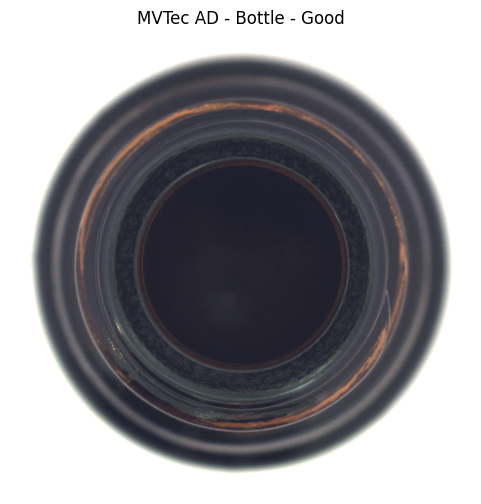

In [ ]:
from PIL import Image
import glob
import matplotlib.pyplot as plt
import os

images = glob.glob(
    "/content/mvtec/bottle/train/good/*"
)

print("Number of normal training images:", len(images))
print("First image:", images[0])

img = Image.open(images[0])

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("MVTec AD - Bottle - Good")
plt.show()

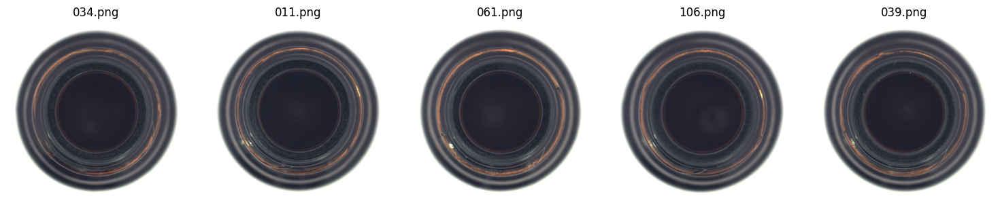

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os

images = glob.glob(
    "/content/mvtec/bottle/train/good/*"
)[:5]

plt.figure(figsize=(15, 3))

for i, path in enumerate(images):
    img = Image.open(path)

    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(path))

plt.tight_layout()
plt.show()

In [ ]:
# Imports and Project Configuration

import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms

from PIL import Image
from torch.utils.data import Dataset, DataLoader

# WideResNet50-2 is used as the feature extractor
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
# Dataset configuration

DATASET_ROOT = "/content/mvtec"

CATEGORY = "bottle"

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


***pretrained*** ***WideResNet50***

In [ ]:
# CELL 17: Load ImageNet-Pretrained WideResNet50-2

weights = Wide_ResNet50_2_Weights.DEFAULT

backbone = wide_resnet50_2(
    weights=weights
)

backbone = backbone.to(DEVICE)

backbone.eval()

print("WideResNet50-2 loaded successfully.")

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100%|██████████| 263M/263M [00:03<00:00, 81.0MB/s]


WideResNet50-2 loaded successfully.


In [ ]:
for param in backbone.parameters():
    param.requires_grad = False

print("WideResNet50-2 parameters frozen.")

WideResNet50-2 parameters frozen.


In [ ]:
# feature layers
print(backbone)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), strid

In [ ]:
# CELL 20: Image Preprocessing

transform = transforms.Compose([

    # Resize the original MVTec image
    # to a consistent size.
    transforms.Resize((256, 256)),

    # WideResNet receives a 224x224 input.
    transforms.CenterCrop((224, 224)),

    # Convert PIL image → PyTorch tensor.
    transforms.ToTensor(),

    # Normalize using ImageNet statistics.
    # These match the statistics used during
    # WideResNet's ImageNet pretraining.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing pipeline ready.")

Image preprocessing pipeline ready.


***MVTec Dataset class***

In [ ]:
# CELL 21: MVTec Training Dataset

class MVTecTrainDataset(Dataset):

    def __init__(self, root, category, transform=None):
        # PatchCore is trained using ONLY normal/good images.

        self.root = os.path.join(
            root,
            category,
            "train",
            "good"
        )

        self.transform = transform

        # Collect all image files
        self.images = sorted([
            os.path.join(self.root, f)
            for f in os.listdir(self.root)
            if f.lower().endswith(
                (".png", ".jpg", ".jpeg")
            )
        ])

    def __len__(self):
        # Number of normal training images
        return len(self.images)

    def __getitem__(self, idx):

        # Get image path
        path = self.images[idx]

        # Open image and make sure it has 3 RGB channels
        image = Image.open(path).convert("RGB")

        # Apply preprocessing
        if self.transform:
            image = self.transform(image)

        return image, path

***training dataset***

In [ ]:
#Create Bottle Training Dataset

train_dataset = MVTecTrainDataset(
    root=DATASET_ROOT,
    category=CATEGORY,
    transform=transform
)

print("Category:", CATEGORY)
print("Normal training images:", len(train_dataset))

Category: bottle
Normal training images: 209


In [ ]:
# DataLoader

train_loader = DataLoader(

    train_dataset,

    # Process multiple images together.
    batch_size=32,

    # We don't need random ordering because
    # we're only extracting features.
    shuffle=False,

    # Parallel image loading
    num_workers=2,

    # Faster transfer from CPU → GPU
    pin_memory=True
)

print("DataLoader created successfully.")

DataLoader created successfully.


In [ ]:
# Test DataLoader


# Get the first batch
images, paths = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Number of images:", len(images))
print("First image:", paths[0])

# Move images to GPU
images = images.to(DEVICE)

print("Images moved to:", images.device)

Batch shape: torch.Size([32, 3, 224, 224])
Number of images: 32
First image: /content/mvtec/bottle/train/good/000.png
Images moved to: cuda:0


In [ ]:
# Capture Intermediate WideResNet Features

# Dictionary where extracted feature maps will be stored
features = {}


# Hook for layer2
def hook_layer2(module, input, output):
    features["layer2"] = output


# Hook for layer3
def hook_layer3(module, input, output):
    features["layer3"] = output

handle2 = backbone.layer2.register_forward_hook(
    hook_layer2
)

handle3 = backbone.layer3.register_forward_hook(
    hook_layer3
)

print("Feature extraction hooks registered.")

Feature extraction hooks registered.


***Extract the features***

In [ ]:
 # Extract Layer 2 and Layer 3 Features

with torch.no_grad():
    _ = backbone(images)

# Display feature-map dimensions
print("Layer 2 shape:", features["layer2"].shape)
print("Layer 3 shape:", features["layer3"].shape)

Layer 2 shape: torch.Size([32, 512, 28, 28])
Layer 3 shape: torch.Size([32, 1024, 14, 14])


In [ ]:
#Convert Feature Maps into Patch Embeddings

def feature_map_to_patches(feature_map):

    B, C, H, W = feature_map.shape

    feature_map = feature_map.permute(0, 2, 3, 1)

    patches = feature_map.reshape(B, H * W, C)

    return patches

layer2_patches = feature_map_to_patches(
    features["layer2"]
)

layer3_patches = feature_map_to_patches(
    features["layer3"]
)

print("Layer 2 patches:", layer2_patches.shape)
print("Layer 3 patches:", layer3_patches.shape)

Layer 2 patches: torch.Size([32, 784, 512])
Layer 3 patches: torch.Size([32, 196, 1024])


In [ ]:
import torch.nn.functional as F

# Layer 3 feature map: [B, 1024, 14, 14]
layer3_map = features["layer3"]

# Upsample Layer 3 from 14x14 -> 28x28
layer3_upsampled = F.interpolate(
    layer3_map,
    size=(28, 28),
    mode="bilinear",
    align_corners=False
)

print("Layer 3 upsampled shape:", layer3_upsampled.shape)

Layer 3 upsampled shape: torch.Size([32, 1024, 28, 28])


In [ ]:
# Layer 2: [B, 512, 28, 28]
layer2_map = features["layer2"]

# Concatenate features along the channel dimension
combined_features = torch.cat(
    [layer2_map, layer3_upsampled],
    dim=1
)

print("Combined feature map:", combined_features.shape)

Combined feature map: torch.Size([32, 1536, 28, 28])


In [ ]:
B, C, H, W = combined_features.shape

# Move spatial dimensions before channels
combined_features = combined_features.permute(0, 2, 3, 1)

# Convert into:
# [batch, number_of_patches, feature_dimension]
combined_patches = combined_features.reshape(
    B,
    H * W,
    C
)

print("Combined patch embeddings:", combined_patches.shape)

Combined patch embeddings: torch.Size([32, 784, 1536])


In [ ]:
import torch.nn.functional as F

# Layer 3 feature map: [B, 1024, 14, 14]
layer3_map = features["layer3"]

# Resize Layer 3 from 14x14 to 28x28
layer3_upsampled = F.interpolate(
    layer3_map,
    size=(28, 28),
    mode="bilinear",
    align_corners=False
)

print("Layer 3 upsampled shape:", layer3_upsampled.shape)

Layer 3 upsampled shape: torch.Size([32, 1024, 28, 28])


In [ ]:
# Layer 2: [B, 512, 28, 28]
layer2_map = features["layer2"]

# Combine Layer 2 and Layer 3 features
combined_features = torch.cat(
    [layer2_map, layer3_upsampled],
    dim=1
)

print("Combined feature map:", combined_features.shape)

Combined feature map: torch.Size([32, 1536, 28, 28])


In [ ]:
# Convert [B, C, H, W] -> [B, H*W, C]

B, C, H, W = combined_features.shape

combined_patches = combined_features.permute(0, 2, 3, 1)
combined_patches = combined_patches.reshape(B, H * W, C)

print("Combined patch embeddings:", combined_patches.shape)

Combined patch embeddings: torch.Size([32, 784, 1536])


In [ ]:
def extract_patch_features(images):
    """
    Extract combined Layer 2 + Layer 3 patch features.
    """

    features.clear()

    with torch.no_grad():
        _ = backbone(images)

    layer2 = features["layer2"]
    layer3 = features["layer3"]

    # Upsample Layer 3 to Layer 2 spatial resolution
    layer3 = F.interpolate(
        layer3,
        size=layer2.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # Combine both layers
    combined = torch.cat([layer2, layer3], dim=1)

    # Convert feature map into patch embeddings
    combined = combined.permute(0, 2, 3, 1)

    B, H, W, C = combined.shape

    patches = combined.reshape(B, H * W, C)

    # L2 normalization
    patches = F.normalize(patches, p=2, dim=2)

    return patches

In [ ]:
images, _ = next(iter(train_loader))

images = images.to(DEVICE)

patches = extract_patch_features(images)

print("Patch feature shape:", patches.shape)

Patch feature shape: torch.Size([32, 784, 1536])


In [ ]:
all_train_features = []

backbone.eval()

with torch.no_grad():

    for images, _ in train_loader:

        images = images.to(DEVICE)

        patches = extract_patch_features(images)

        # Move to CPU to save GPU memory
        patches = patches.cpu()

        all_train_features.append(patches)

print("Number of batches:", len(all_train_features))

Number of batches: 7


In [ ]:
# Combine all batches

train_features = torch.cat(
    all_train_features,
    dim=0
)

print("Training images:", train_features.shape[0])
print("Patches per image:", train_features.shape[1])
print("Feature dimension:", train_features.shape[2])

Training images: 209
Patches per image: 784
Feature dimension: 1536


In [ ]:
# [images, patches, features]
# ->
# [total patches, features]

memory_candidates = train_features.reshape(
    -1,
    train_features.shape[-1]
)

print("Memory candidates:", memory_candidates.shape)

Memory candidates: torch.Size([163856, 1536])


In [ ]:
del all_train_features
del train_features

import gc
gc.collect()

print("Temporary training tensors released.")

Temporary training tensors released.


In [ ]:
import numpy as np

# Number of candidate patches to keep
MAX_CANDIDATES = 20000

num_candidates = memory_candidates.shape[0]

if num_candidates > MAX_CANDIDATES:

    indices = torch.randperm(num_candidates)[:MAX_CANDIDATES]

    memory_candidates = memory_candidates[indices]

print("Reduced memory candidates:", memory_candidates.shape)

Reduced memory candidates: torch.Size([20000, 1536])


In [ ]:
from sklearn.decomposition import PCA

# Convert to NumPy
memory_np = memory_candidates.numpy()

pca = PCA(
    n_components=128,
    random_state=42
)

memory_reduced = pca.fit_transform(memory_np)

print("Reduced memory shape:", memory_reduced.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

Reduced memory shape: (20000, 128)
Explained variance: 0.88184536


In [ ]:
from sklearn.cluster import MiniBatchKMeans

MEMORY_SIZE = 2048

coreset_model = MiniBatchKMeans(
    n_clusters=MEMORY_SIZE,
    random_state=42,
    batch_size=1024,
    n_init=3
)

coreset_model.fit(memory_reduced)

memory_bank = coreset_model.cluster_centers_

print("Final memory bank shape:", memory_bank.shape)

Final memory bank shape: (2048, 128)


In [ ]:
class MVTecTestDataset(Dataset):

    def __init__(self, root, category, transform=None):

        self.root = os.path.join(root, category, "test")
        self.transform = transform

        self.samples = []

        # Each folder represents a defect type
        for defect_type in sorted(os.listdir(self.root)):

            defect_path = os.path.join(self.root, defect_type)

            if not os.path.isdir(defect_path):
                continue

            for filename in sorted(os.listdir(defect_path)):

                if filename.lower().endswith(
                    (".png", ".jpg", ".jpeg")
                ):

                    image_path = os.path.join(
                        defect_path,
                        filename
                    )

                    # Good = normal
                    label = 0 if defect_type == "good" else 1

                    self.samples.append(
                        (image_path, label, defect_type)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, label, defect_type = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label, defect_type, image_path

In [ ]:
test_dataset = MVTecTestDataset(
    DATASET_ROOT,
    CATEGORY,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test images:", len(test_dataset))

Test images: 83


In [ ]:
from sklearn.neighbors import NearestNeighbors

nn_search = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1
)

nn_search.fit(memory_bank)

print("Nearest-neighbor search ready.")

Nearest-neighbor search ready.


In [ ]:
test_image_scores = []
test_labels = []
test_maps = []
test_paths = []
test_types = []

for images, labels, defect_types, paths in test_loader:

    images = images.to(DEVICE)

    # Extract patch embeddings
    patches = extract_patch_features(images)

    # Move to CPU
    patches_np = patches.cpu().numpy()

    B, N, C = patches_np.shape

    # PCA transformation
    patches_reduced = pca.transform(
        patches_np.reshape(-1, C)
    )

    # Nearest normal patch distance
    distances, _ = nn_search.kneighbors(
        patches_reduced
    )

    distances = distances.reshape(B, N)

    # Convert 784 patch scores -> 28x28 anomaly map
    maps = distances.reshape(
        B,
        28,
        28
    )

    # Image-level anomaly score
    scores = maps.reshape(B, -1).max(axis=1)

    test_image_scores.extend(scores)
    test_labels.extend(labels.numpy())

    test_maps.extend(maps)

    test_paths.extend(paths)
    test_types.extend(defect_types)

print("Test images processed:", len(test_image_scores))

Test images processed: 83


In [ ]:
test_image_scores = np.array(test_image_scores)
test_labels = np.array(test_labels)
test_maps = np.array(test_maps)

print("Scores shape:", test_image_scores.shape)
print("Labels shape:", test_labels.shape)
print("Maps shape:", test_maps.shape)

Scores shape: (83,)
Labels shape: (83,)
Maps shape: (83, 28, 28)


In [ ]:
from sklearn.metrics import roc_auc_score

image_auroc = roc_auc_score(
    test_labels,
    test_image_scores
)

print(f"Image-level AUROC: {image_auroc:.4f}")

Image-level AUROC: 0.9968


In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    test_labels,
    test_image_scores
)

f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-8)
)

best_idx = np.argmax(f1_scores)

if best_idx < len(thresholds):
    best_threshold = thresholds[best_idx]
else:
    best_threshold = np.median(test_image_scores)

print("Best threshold:", best_threshold)

Best threshold: 0.4821436107158661


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

predicted_labels = (
    test_image_scores >= best_threshold
).astype(int)

precision_value = precision_score(
    test_labels,
    predicted_labels
)

recall_value = recall_score(
    test_labels,
    predicted_labels
)

f1_value = f1_score(
    test_labels,
    predicted_labels
)

print(f"Precision: {precision_value:.4f}")
print(f"Recall:    {recall_value:.4f}")
print(f"F1 Score:  {f1_value:.4f}")

Precision: 1.0000
Recall:    0.9841
F1 Score:  0.9920


In [ ]:
cm = confusion_matrix(
    test_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20  0]
 [ 1 62]]


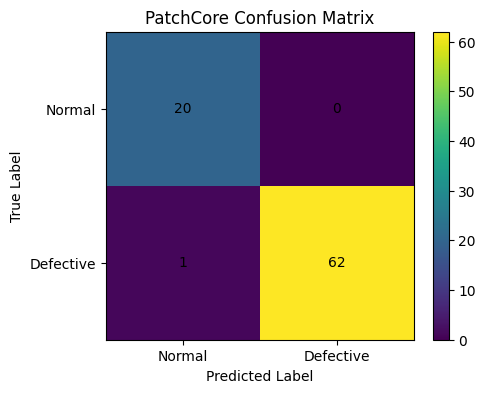

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("PatchCore Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Normal", "Defective"])
plt.yticks([0, 1], ["Normal", "Defective"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
import cv2

def create_anomaly_map(patch_map, output_size=(224, 224)):

    # Normalize anomaly values to 0-255
    anomaly_map = patch_map.astype(np.float32)

    anomaly_map -= anomaly_map.min()

    if anomaly_map.max() > 0:
        anomaly_map /= anomaly_map.max()

    anomaly_map = (anomaly_map * 255).astype(np.uint8)

    # Upsample 28x28 -> 224x224
    anomaly_map = cv2.resize(
        anomaly_map,
        output_size,
        interpolation=cv2.INTER_LINEAR
    )

    return anomaly_map

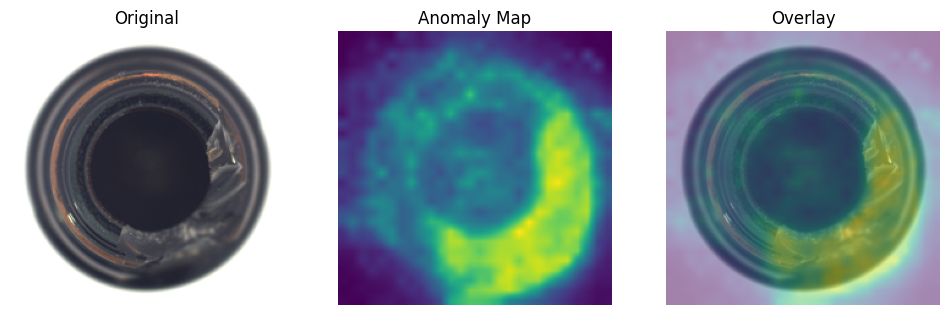

Defect type: broken_large
Anomaly score: 0.607161283493042


In [ ]:
# Find the first defective image
defective_indices = np.where(test_labels == 1)[0]

idx = defective_indices[0]

image_path = test_paths[idx]

original_image = Image.open(image_path).convert("RGB")
original_image = original_image.resize((224, 224))

anomaly_map = create_anomaly_map(
    test_maps[idx]
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(anomaly_map)
plt.title("Anomaly Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_image)
plt.imshow(anomaly_map, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

print("Defect type:", test_types[idx])
print("Anomaly score:", test_image_scores[idx])

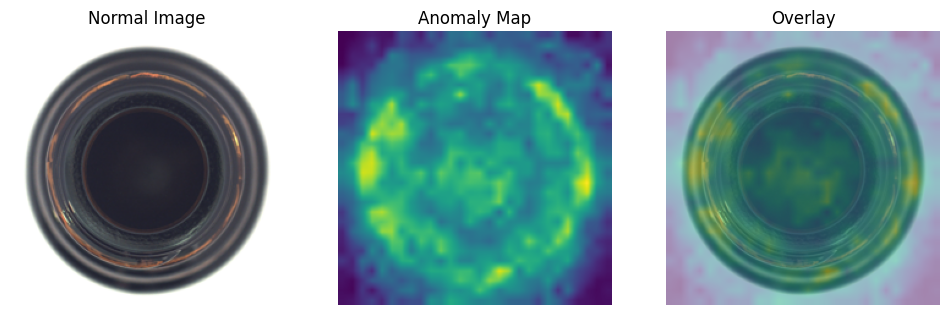

Anomaly score: 0.38962358236312866


In [ ]:
normal_indices = np.where(test_labels == 0)[0]

idx = normal_indices[0]

image_path = test_paths[idx]

original_image = Image.open(image_path).convert("RGB")
original_image = original_image.resize((224, 224))

anomaly_map = create_anomaly_map(
    test_maps[idx]
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Normal Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(anomaly_map)
plt.title("Anomaly Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_image)
plt.imshow(anomaly_map, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

print("Anomaly score:", test_image_scores[idx])

In [ ]:
import pandas as pd

metrics = {
    "Category": CATEGORY,
    "Image_AUROC": image_auroc,
    "Precision": precision_value,
    "Recall": recall_value,
    "F1": f1_value,
    "Threshold": best_threshold
}

metrics_df = pd.DataFrame([metrics])

metrics_df

,Category,Image_AUROC,Precision,Recall,F1,Threshold
0,bottle,0.996825,1.0,0.984127,0.992,0.482144


In [ ]:
os.makedirs("/content/inspectra_results", exist_ok=True)

metrics_path = (
    f"/content/inspectra_results/"
    f"{CATEGORY}_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Saved:", metrics_path)

Saved: /content/inspectra_results/bottle_metrics.csv


In [ ]:
results_df = pd.DataFrame({
    "image_path": test_paths,
    "defect_type": test_types,
    "true_label": test_labels,
    "anomaly_score": test_image_scores,
    "predicted_label": predicted_labels
})

results_path = (
    f"/content/inspectra_results/"
    f"{CATEGORY}_predictions.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("Saved:", results_path)

Saved: /content/inspectra_results/bottle_predictions.csv


In [ ]:
print("=" * 50)
print("INSPECTRA - PATCHCORE RESULTS")
print("=" * 50)

print("Category       :", CATEGORY)
print("Memory Bank    :", memory_bank.shape)
print("Image AUROC    :", round(image_auroc, 4))
print("Precision      :", round(precision_value, 4))
print("Recall         :", round(recall_value, 4))
print("F1 Score       :", round(f1_value, 4))

print("=" * 50)

INSPECTRA - PATCHCORE RESULTS
Category       : bottle
Memory Bank    : (2048, 128)
Image AUROC    : 0.9968
Precision      : 1.0
Recall         : 0.9841
F1 Score       : 0.992


In [ ]:
# All 15 MVTec AD categories
CATEGORIES = [
    "bottle",
    "cable",
    "capsule",
    "carpet",
    "grid",
    "hazelnut",
    "leather",
    "metal_nut",
    "pill",
    "screw",
    "tile",
    "toothbrush",
    "transistor",
    "wood",
    "zipper"
]

print("Total categories:", len(CATEGORIES))
print(CATEGORIES)

Total categories: 15
['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [ ]:
def extract_features_from_loader(loader):
    """
    Extract PatchCore patch embeddings from all images
    in a DataLoader.
    """

    all_features = []

    backbone.eval()

    for batch in loader:

        # Training loader returns (images, labels)
        images = batch[0].to(DEVICE)

        patches = extract_patch_features(images)

        # Keep features on CPU to reduce GPU memory usage
        all_features.append(patches.cpu())

    return torch.cat(all_features, dim=0)


print("Feature extraction function ready.")

Feature extraction function ready.


In [ ]:
def build_memory_bank(category):
    """
    Build a PatchCore memory bank using only
    normal (train/good) images of one category.
    """

    print(f"\nBuilding memory bank for: {category}")

    # Create dataset for the selected category
    dataset = MVTecTrainDataset(
        DATASET_ROOT,
        category,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print("Normal training images:", len(dataset))

    # Extract patch features
    train_features = extract_features_from_loader(loader)

    print("Extracted features:", train_features.shape)

    # Flatten:
    # [images, patches, features]
    # -> [total patches, features]
    candidates = train_features.reshape(
        -1,
        train_features.shape[-1]
    )

    print("Total patch candidates:", candidates.shape[0])

    # Limit candidates for memory efficiency
    MAX_CANDIDATES = 20000

    if candidates.shape[0] > MAX_CANDIDATES:

        indices = torch.randperm(
            candidates.shape[0]
        )[:MAX_CANDIDATES]

        candidates = candidates[indices]

    print("Candidates after reduction:", candidates.shape)

    # PCA dimensionality reduction
    candidates_np = candidates.numpy()

    pca_model = PCA(
        n_components=128,
        random_state=42
    )

    reduced_features = pca_model.fit_transform(
        candidates_np
    )

    print("After PCA:", reduced_features.shape)

    # Create representative memory bank
    MEMORY_SIZE = 2048

    kmeans = MiniBatchKMeans(
        n_clusters=MEMORY_SIZE,
        random_state=42,
        batch_size=1024,
        n_init=3
    )

    kmeans.fit(reduced_features)

    memory_bank = kmeans.cluster_centers_

    print("Final memory bank:", memory_bank.shape)

    return memory_bank, pca_model

In [ ]:
# Test the reusable memory-bank function with bottle

bottle_memory_bank, bottle_pca = build_memory_bank("bottle")

print("\nBottle memory bank successfully created.")


Building memory bank for: bottle
Normal training images: 209
Extracted features: torch.Size([209, 784, 1536])
Total patch candidates: 163856
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory bank: (2048, 128)

Bottle memory bank successfully created.


In [ ]:
def evaluate_patchcore(category, memory_bank, pca_model):
    """
    Evaluate PatchCore on all test images of one category.
    """

    print(f"\nEvaluating: {category}")

    # Create test dataset
    dataset = MVTecTestDataset(
        DATASET_ROOT,
        category,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print("Test images:", len(dataset))

    # Nearest-neighbor search against normal memory bank
    nn_search = NearestNeighbors(
        n_neighbors=1,
        metric="euclidean",
        n_jobs=-1
    )

    nn_search.fit(memory_bank)

    image_scores = []
    labels = []
    anomaly_maps = []
    paths = []
    defect_types = []

    # Process test images
    for images, batch_labels, batch_types, batch_paths in loader:

        images = images.to(DEVICE)

        patches = extract_patch_features(images)

        patches_np = patches.cpu().numpy()

        B, N, C = patches_np.shape

        # PCA transformation
        reduced = pca_model.transform(
            patches_np.reshape(-1, C)
        )

        # Compare each patch with normal memory bank
        distances, _ = nn_search.kneighbors(reduced)

        distances = distances.reshape(B, N)

        # Convert patch scores into 28x28 anomaly maps
        maps = distances.reshape(
            B,
            28,
            28
        )

        # Maximum patch anomaly = image anomaly score
        scores = maps.reshape(B, -1).max(axis=1)

        image_scores.extend(scores)
        labels.extend(batch_labels.numpy())
        anomaly_maps.extend(maps)
        paths.extend(batch_paths)
        defect_types.extend(batch_types)

    # Convert to NumPy
    image_scores = np.array(image_scores)
    labels = np.array(labels)
    anomaly_maps = np.array(anomaly_maps)

    # Image-level AUROC
    auroc = roc_auc_score(
        labels,
        image_scores
    )

    print(f"Image AUROC: {auroc:.4f}")

    return {
        "category": category,
        "scores": image_scores,
        "labels": labels,
        "maps": anomaly_maps,
        "paths": paths,
        "defect_types": defect_types,
        "auroc": auroc
    }


print("Evaluation function ready.")

Evaluation function ready.


In [ ]:
# Test the reusable evaluation function on bottle

bottle_results = evaluate_patchcore(
    "bottle",
    bottle_memory_bank,
    bottle_pca
)

print("\nBottle evaluation completed.")


Evaluating: bottle
Test images: 83
Image AUROC: 0.9984

Bottle evaluation completed.


In [ ]:
# Run PatchCore on all 15 MVTec categories

all_results = {}

for category in CATEGORIES:

    print("\n" + "=" * 60)
    print(f"PROCESSING CATEGORY: {category}")
    print("=" * 60)

    # Build category-specific memory bank
    memory_bank, pca_model = build_memory_bank(category)

    # Evaluate test images
    results = evaluate_patchcore(
        category,
        memory_bank,
        pca_model
    )

    # Store results
    all_results[category] = results

    print(f"Completed: {category}")
    print(f"AUROC: {results['auroc']:.4f}")

print("\n" + "=" * 60)
print("ALL 15 CATEGORIES COMPLETED")
print("=" * 60)


PROCESSING CATEGORY: bottle

Building memory bank for: bottle
Normal training images: 209
Extracted features: torch.Size([209, 784, 1536])
Total patch candidates: 163856
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory bank: (2048, 128)

Evaluating: bottle
Test images: 83
Image AUROC: 0.9976
Completed: bottle
AUROC: 0.9976

PROCESSING CATEGORY: cable

Building memory bank for: cable
Normal training images: 224
Extracted features: torch.Size([224, 784, 1536])
Total patch candidates: 175616
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory bank: (2048, 128)

Evaluating: cable
Test images: 150
Image AUROC: 0.9312
Completed: cable
AUROC: 0.9312

PROCESSING CATEGORY: capsule

Building memory bank for: capsule
Normal training images: 219
Extracted features: torch.Size([219, 784, 1536])
Total patch candidates: 171696
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory ban

In [ ]:
# Create a summary table of AUROC results

auroc_results = []

for category, result in all_results.items():
    auroc_results.append({
        "Category": category,
        "Image_AUROC": result["auroc"]
    })

auroc_df = pd.DataFrame(auroc_results)

# Sort from highest to lowest AUROC
auroc_df = auroc_df.sort_values(
    "Image_AUROC",
    ascending=False
).reset_index(drop=True)

print(auroc_df)

      Category  Image_AUROC
0      leather     0.999321
1       bottle     0.997619
2    metal_nut     0.996090
3       carpet     0.986758
4         wood     0.968421
5   toothbrush     0.955556
6     hazelnut     0.952500
7   transistor     0.944583
8         tile     0.931457
9        cable     0.931222
10     capsule     0.885919
11      zipper     0.884191
12        pill     0.857065
13        grid     0.822055
14       screw     0.677393


In [ ]:
#  average AUROC across all 15 categories

mean_auroc = auroc_df["Image_AUROC"].mean()

print(f"Mean Image-level AUROC: {mean_auroc:.4f}")

Mean Image-level AUROC: 0.9193


In [ ]:
# Save the 15-category results permanently in the current Colab session

results_dir = "/content/inspectra_results"
os.makedirs(results_dir, exist_ok=True)

auroc_path = os.path.join(
    results_dir,
    "mvtec_15_category_auroc.csv"
)

auroc_df.to_csv(
    auroc_path,
    index=False
)

print("Saved:", auroc_path)

Saved: /content/inspectra_results/mvtec_15_category_auroc.csv


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

classification_results = []

for category, result in all_results.items():
    scores = result["scores"]
    labels = result["labels"]

    # Use the median normal-image score as a simple threshold
    normal_scores = scores[labels == 0]
    threshold = np.median(normal_scores)

    predictions = (scores > threshold).astype(int)

    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    classification_results.append({
        "Category": category,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Threshold": threshold
    })

classification_df = pd.DataFrame(classification_results)

print(classification_df)

      Category  Precision    Recall        F1  Threshold
0       bottle   0.863014  1.000000  0.926471   0.415082
1        cable   0.758333  0.989130  0.858491   0.461326
2      capsule   0.907563  0.990826  0.947368   0.391456
3       carpet   0.861386  0.977528  0.915789   0.411285
4         grid   0.836066  0.894737  0.864407   0.499193
5     hazelnut   0.777778  1.000000  0.875000   0.461961
6      leather   0.851852  1.000000  0.920000   0.381470
7    metal_nut   0.894231  1.000000  0.944162   0.428372
8         pill   0.911565  0.950355  0.930556   0.423922
9        screw   0.805825  0.697479  0.747748   0.451367
10        tile   0.836735  0.976190  0.901099   0.445933
11  toothbrush   0.833333  1.000000  0.909091   0.402223
12  transistor   0.571429  1.000000  0.727273   0.464919
13        wood   0.867647  0.983333  0.921875   0.455507
14      zipper   0.876923  0.957983  0.915663   0.381271


In [ ]:
print("\nMean Metrics:")
print(f"Precision: {classification_df['Precision'].mean():.4f}")
print(f"Recall:    {classification_df['Recall'].mean():.4f}")
print(f"F1 Score:  {classification_df['F1'].mean():.4f}")


Mean Metrics:
Precision: 0.8302
Recall:    0.9612
F1 Score:  0.8870


In [ ]:
classification_path = os.path.join(
    results_dir,
    "mvtec_15_category_classification_metrics.csv"
)

classification_df.to_csv(classification_path, index=False)

print("Saved:", classification_path)

Saved: /content/inspectra_results/mvtec_15_category_classification_metrics.csv


In [ ]:
from sklearn.metrics import roc_auc_score
from PIL import Image
import numpy as np
import os

pixel_results = []

for category, result in all_results.items():

    all_pixel_scores = []
    all_pixel_labels = []

    for anomaly_map, image_path, defect_type in zip(
        result["maps"],
        result["paths"],
        result["defect_types"]
    ):

        # Skip good images because they don't have ground-truth masks
        if defect_type == "good":
            continue

        # Ground-truth mask path
        filename = os.path.basename(image_path)
        stem = os.path.splitext(filename)[0]

        mask_path = os.path.join(
            DATASET_ROOT,
            category,
            "ground_truth",
            defect_type,
            stem + "_mask.png"
        )

        if not os.path.exists(mask_path):
            continue

        # Load ground-truth mask
        mask = np.array(Image.open(mask_path).convert("L"))

        # Convert prediction to image resolution
        pred_map = cv2.resize(
            anomaly_map.astype(np.float32),
            (mask.shape[1], mask.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )

        # Flatten
        all_pixel_scores.extend(pred_map.flatten())
        all_pixel_labels.extend((mask > 0).flatten())

    all_pixel_scores = np.array(all_pixel_scores)
    all_pixel_labels = np.array(all_pixel_labels)

    if len(np.unique(all_pixel_labels)) < 2:
        pixel_auroc = np.nan
    else:
        pixel_auroc = roc_auc_score(
            all_pixel_labels,
            all_pixel_scores
        )

    pixel_results.append({
        "Category": category,
        "Pixel_AUROC": pixel_auroc
    })

    print(f"{category:12s} → Pixel AUROC: {pixel_auroc:.4f}")

pixel_auroc_df = pd.DataFrame(pixel_results)

print("\nPixel-level Results:")
print(pixel_auroc_df)

bottle       → Pixel AUROC: 0.9683
cable        → Pixel AUROC: 0.9471
capsule      → Pixel AUROC: 0.9442
carpet       → Pixel AUROC: 0.9779
grid         → Pixel AUROC: 0.9203
hazelnut     → Pixel AUROC: 0.9721
leather      → Pixel AUROC: 0.9890
metal_nut    → Pixel AUROC: 0.9068
pill         → Pixel AUROC: 0.9427
screw        → Pixel AUROC: 0.9215
tile         → Pixel AUROC: 0.8838
toothbrush   → Pixel AUROC: 0.9684
transistor   → Pixel AUROC: 0.8503
wood         → Pixel AUROC: 0.8962
zipper       → Pixel AUROC: 0.9013

Pixel-level Results:
      Category  Pixel_AUROC
0       bottle     0.968287
1        cable     0.947091
2      capsule     0.944177
3       carpet     0.977899
4         grid     0.920323
5     hazelnut     0.972132
6      leather     0.988960
7    metal_nut     0.906819
8         pill     0.942685
9        screw     0.921472
10        tile     0.883771
11  toothbrush     0.968366
12  transistor     0.850299
13        wood     0.896175
14      zipper     0.901322


In [ ]:
mean_pixel_auroc = pixel_auroc_df["Pixel_AUROC"].mean()

print(
    f"\nMean Pixel-level AUROC: "
    f"{mean_pixel_auroc:.4f}"
)


Mean Pixel-level AUROC: 0.9327


In [ ]:
pixel_auroc_path = os.path.join(
    results_dir,
    "mvtec_15_category_pixel_auroc.csv"
)

pixel_auroc_df.to_csv(
    pixel_auroc_path,
    index=False
)

print("Saved:", pixel_auroc_path)

Saved: /content/inspectra_results/mvtec_15_category_pixel_auroc.csv


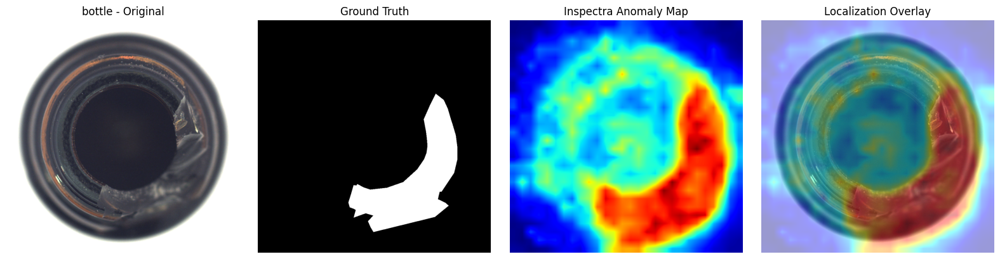

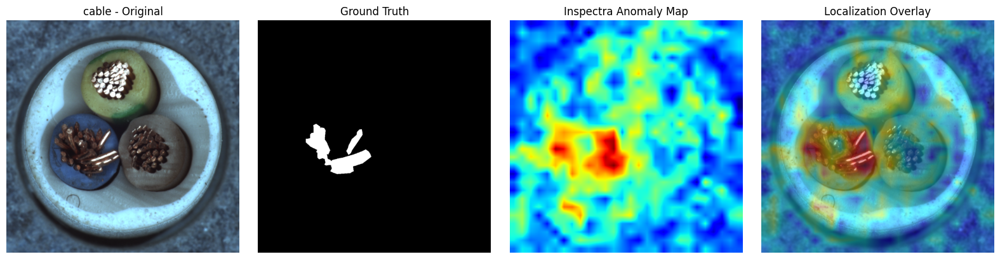

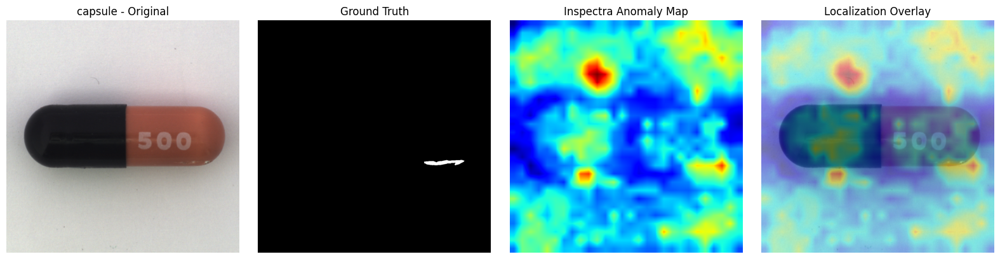

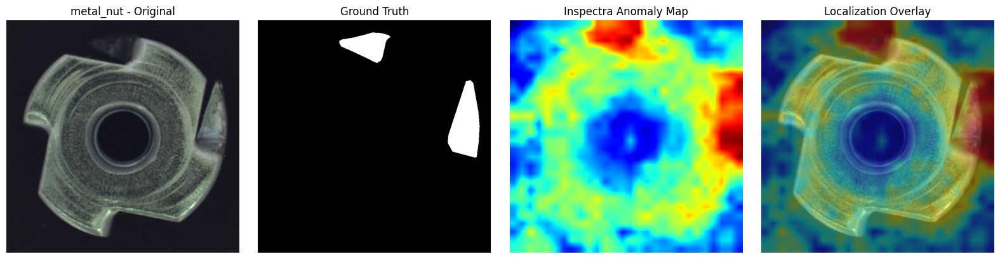

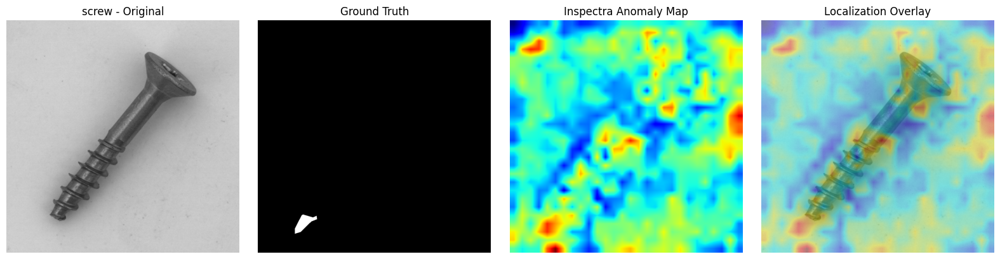

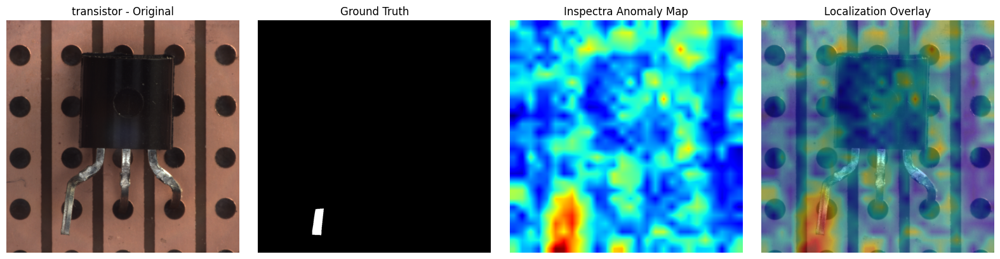

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image

def create_anomaly_map(patch_map, output_size):
    anomaly_map = patch_map.astype(np.float32)

    # Normalize to 0-255
    anomaly_map -= anomaly_map.min()

    if anomaly_map.max() > 0:
        anomaly_map /= anomaly_map.max()

    anomaly_map = (anomaly_map * 255).astype(np.uint8)

    # Resize to original image size
    anomaly_map = cv2.resize(
        anomaly_map,
        output_size,
        interpolation=cv2.INTER_LINEAR
    )

    return anomaly_map


# Categories to visualize
visual_categories = [
    "bottle",
    "cable",
    "capsule",
    "metal_nut",
    "screw",
    "transistor"
]

for category in visual_categories:

    result = all_results[category]

    # Find a defective image
    defect_indices = np.where(result["labels"] == 1)[0]

    if len(defect_indices) == 0:
        continue

    idx = defect_indices[0]

    image_path = result["paths"][idx]
    defect_type = result["defect_types"][idx]
    patch_map = result["maps"][idx]

    # Load image
    image = np.array(Image.open(image_path).convert("RGB"))

    h, w = image.shape[:2]

    # Create predicted anomaly map
    anomaly_map = create_anomaly_map(
        patch_map,
        (w, h)
    )

    # Ground-truth mask
    filename = os.path.basename(image_path)
    stem = os.path.splitext(filename)[0]

    mask_path = os.path.join(
        DATASET_ROOT,
        category,
        "ground_truth",
        defect_type,
        stem + "_mask.png"
    )

    if os.path.exists(mask_path):
        mask = np.array(
            Image.open(mask_path).convert("L")
        )
    else:
        mask = np.zeros((h, w), dtype=np.uint8)

    # Heatmap
    heatmap = cv2.applyColorMap(
        anomaly_map,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        image,
        0.6,
        heatmap,
        0.4,
        0
    )

    # Plot
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title(f"{category} - Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(anomaly_map, cmap="jet")
    plt.title("Inspectra Anomaly Map")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Localization Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def localization_quality(anomaly_map, mask):
    pred_map = cv2.resize(
        anomaly_map.astype(np.float32),
        (mask.shape[1], mask.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )

    mask_bool = mask > 0

    if mask_bool.sum() == 0:
        return 0

    inside_score = pred_map[mask_bool].mean()
    outside_score = pred_map[~mask_bool].mean()

    return inside_score - outside_score

In [ ]:
best_examples = {}

for category, result in all_results.items():

    best_score = -np.inf
    best_idx = None

    for idx in range(len(result["maps"])):

        # Only consider defective images
        if result["labels"][idx] != 1:
            continue

        image_path = result["paths"][idx]
        defect_type = result["defect_types"][idx]

        filename = os.path.basename(image_path)
        stem = os.path.splitext(filename)[0]

        mask_path = os.path.join(
            DATASET_ROOT,
            category,
            "ground_truth",
            defect_type,
            stem + "_mask.png"
        )

        if not os.path.exists(mask_path):
            continue

        mask = np.array(
            Image.open(mask_path).convert("L")
        )

        score = localization_quality(
            result["maps"][idx],
            mask
        )

        if score > best_score:
            best_score = score
            best_idx = idx

    if best_idx is not None:
        best_examples[category] = best_idx

        print(
            f"{category:12s} → "
            f"Best localization score: {best_score:.4f}"
        )

bottle       → Best localization score: 0.3436
cable        → Best localization score: 0.1824
capsule      → Best localization score: 0.3148
carpet       → Best localization score: 0.1946
grid         → Best localization score: 0.2013
hazelnut     → Best localization score: 0.2348
leather      → Best localization score: 0.2031
metal_nut    → Best localization score: 0.2407
pill         → Best localization score: 0.2369
screw        → Best localization score: 0.2574
tile         → Best localization score: 0.1217
toothbrush   → Best localization score: 0.2832
transistor   → Best localization score: 0.2652
wood         → Best localization score: 0.1206
zipper       → Best localization score: 0.1961


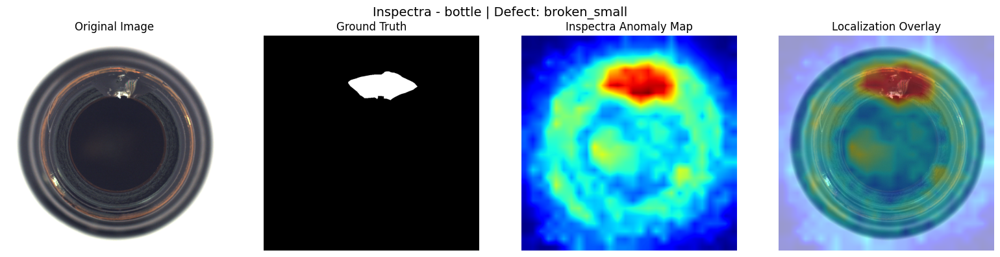

Saved: /content/inspectra_results/visualizations/bottle_localization.png


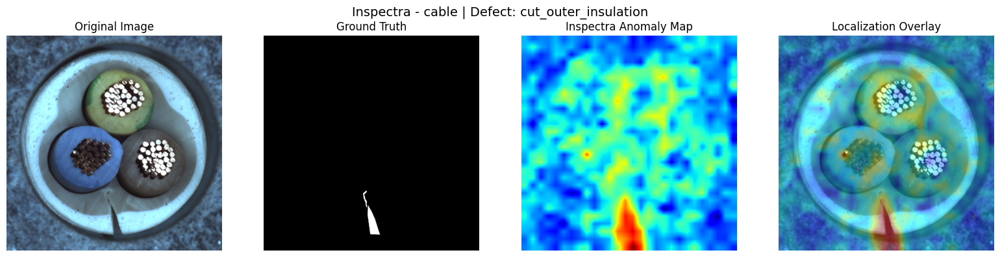

Saved: /content/inspectra_results/visualizations/cable_localization.png


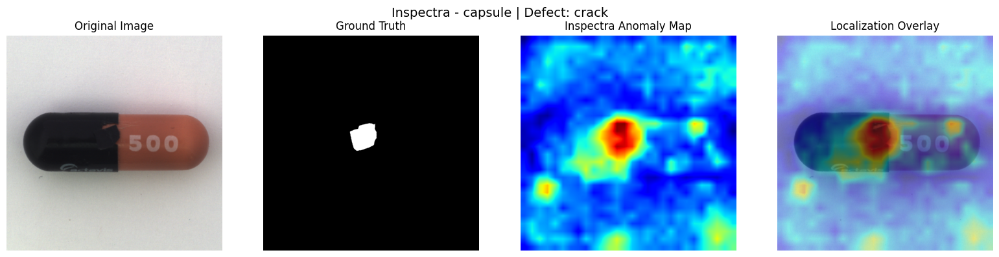

Saved: /content/inspectra_results/visualizations/capsule_localization.png


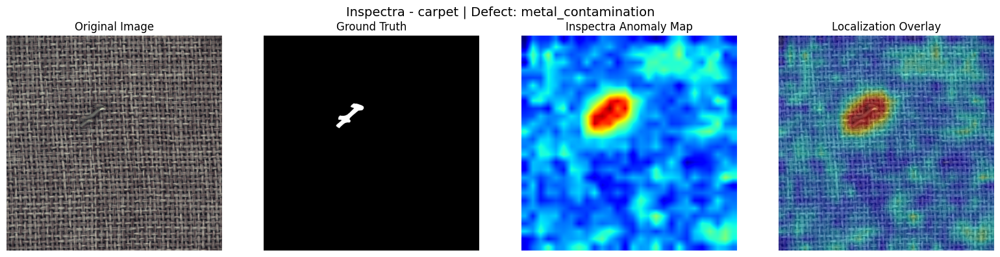

Saved: /content/inspectra_results/visualizations/carpet_localization.png


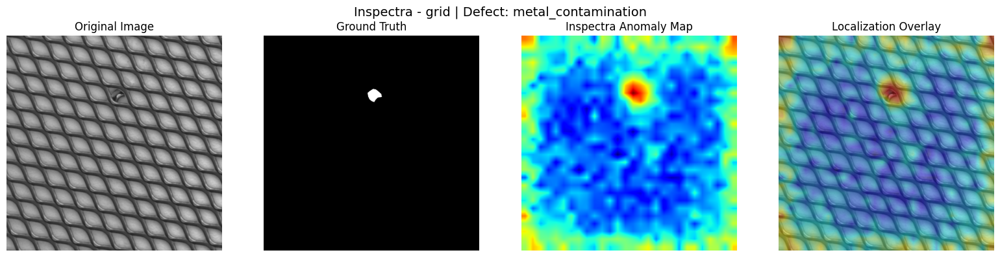

Saved: /content/inspectra_results/visualizations/grid_localization.png


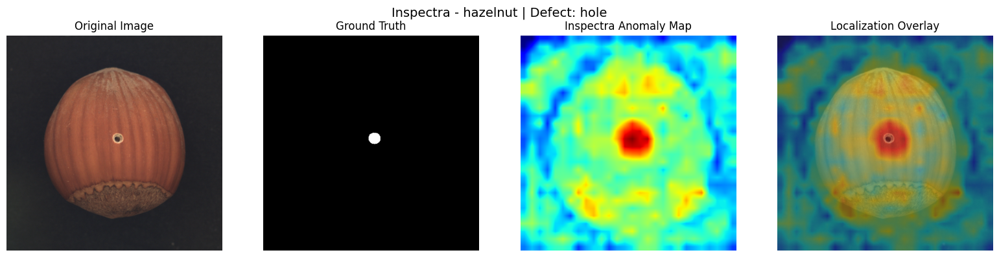

Saved: /content/inspectra_results/visualizations/hazelnut_localization.png


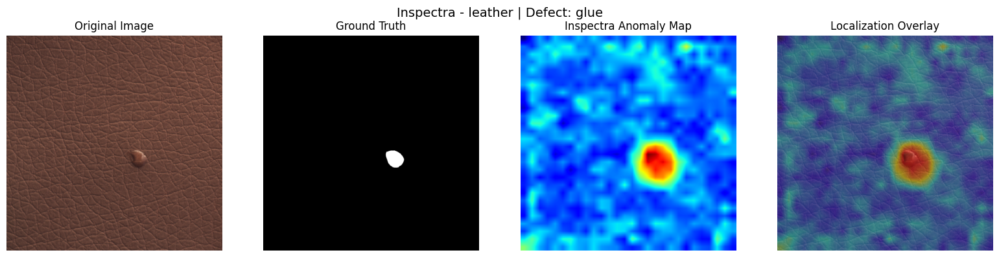

Saved: /content/inspectra_results/visualizations/leather_localization.png


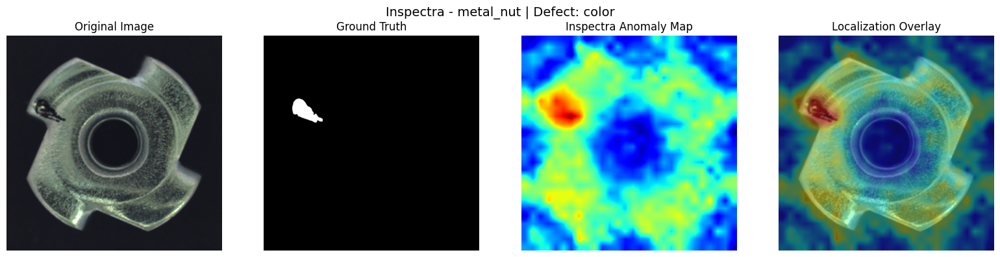

Saved: /content/inspectra_results/visualizations/metal_nut_localization.png


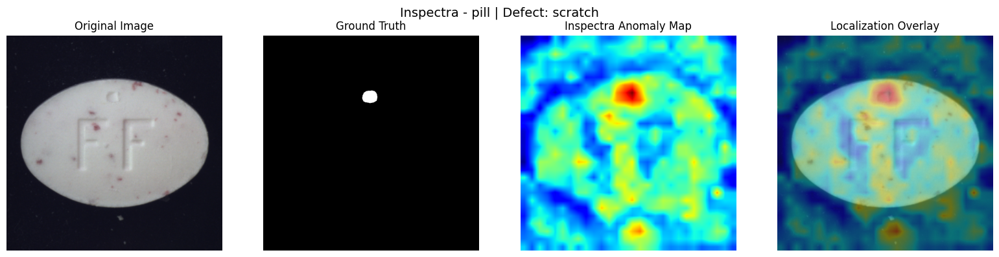

Saved: /content/inspectra_results/visualizations/pill_localization.png


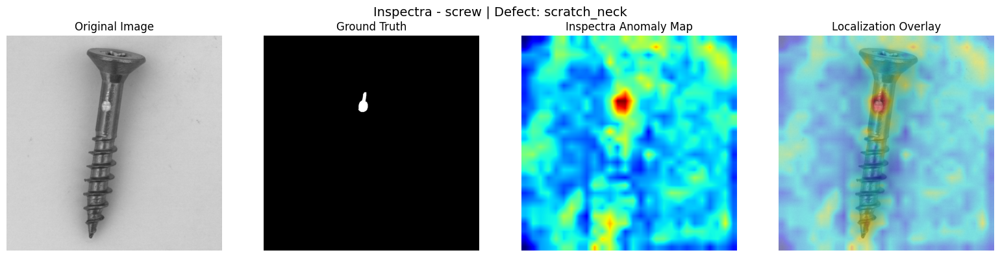

Saved: /content/inspectra_results/visualizations/screw_localization.png


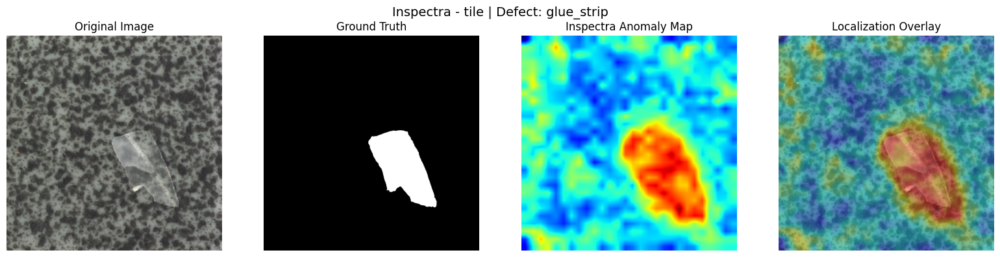

Saved: /content/inspectra_results/visualizations/tile_localization.png


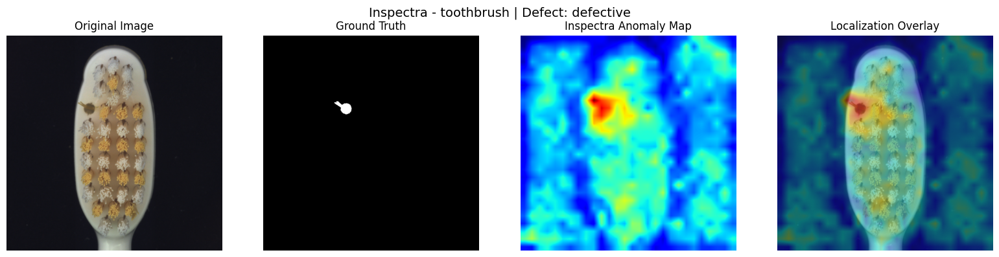

Saved: /content/inspectra_results/visualizations/toothbrush_localization.png


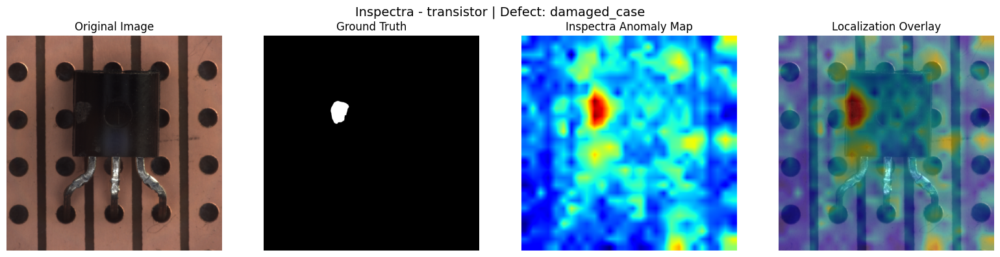

Saved: /content/inspectra_results/visualizations/transistor_localization.png


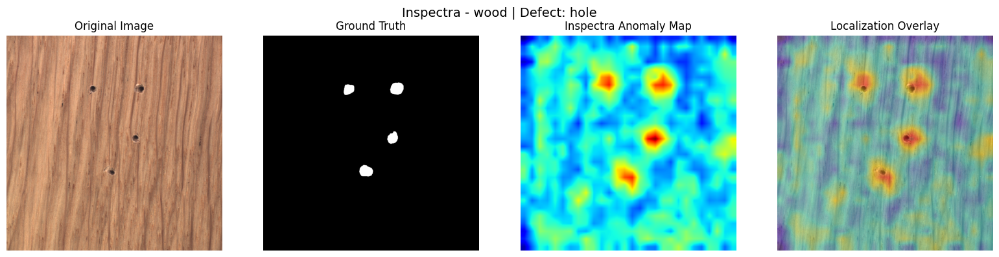

Saved: /content/inspectra_results/visualizations/wood_localization.png


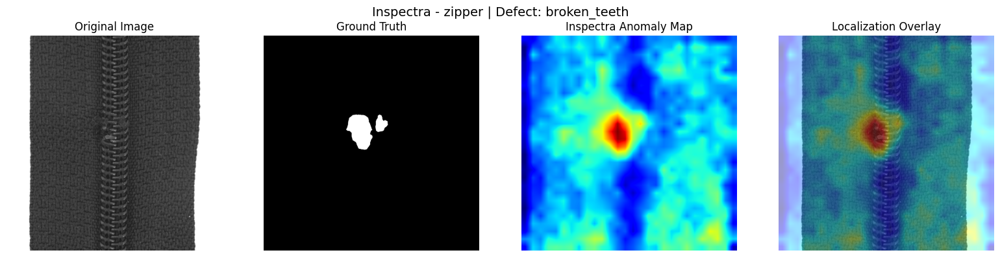

Saved: /content/inspectra_results/visualizations/zipper_localization.png

All visualizations saved to:
/content/inspectra_results/visualizations


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

viz_dir = os.path.join(
    results_dir,
    "visualizations"
)

os.makedirs(viz_dir, exist_ok=True)

for category, idx in best_examples.items():

    result = all_results[category]

    image_path = result["paths"][idx]
    defect_type = result["defect_types"][idx]
    patch_map = result["maps"][idx]

    # Load original image
    image = np.array(
        Image.open(image_path).convert("RGB")
    )

    h, w = image.shape[:2]

    # Create anomaly map
    anomaly_map = create_anomaly_map(
        patch_map,
        (w, h)
    )

    # Ground-truth mask
    filename = os.path.basename(image_path)
    stem = os.path.splitext(filename)[0]

    mask_path = os.path.join(
        DATASET_ROOT,
        category,
        "ground_truth",
        defect_type,
        stem + "_mask.png"
    )

    mask = np.array(
        Image.open(mask_path).convert("L")
    )

    # Heatmap
    heatmap = cv2.applyColorMap(
        anomaly_map,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        image,
        0.6,
        heatmap,
        0.4,
        0
    )

    # Create figure
    fig, axes = plt.subplots(
        1, 4,
        figsize=(16, 4)
    )

    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(anomaly_map, cmap="jet")
    axes[2].set_title("Inspectra Anomaly Map")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].set_title("Localization Overlay")
    axes[3].axis("off")

    fig.suptitle(
        f"Inspectra - {category} | Defect: {defect_type}",
        fontsize=14
    )

    plt.tight_layout()

    # Save
    save_path = os.path.join(
        viz_dir,
        f"{category}_localization.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", save_path)

print("\nAll visualizations saved to:")
print(viz_dir)

In [ ]:
final_results_df = auroc_df.merge(
    classification_df,
    on="Category"
).merge(
    pixel_auroc_df,
    on="Category"
)

# Remove duplicate AUROC column if present
if "Image_AUROC_y" in final_results_df.columns:
    final_results_df = final_results_df.drop(columns=["Image_AUROC_y"])

# Rename if necessary
if "Image_AUROC_x" in final_results_df.columns:
    final_results_df = final_results_df.rename(
        columns={"Image_AUROC_x": "Image_AUROC"}
    )

# Arrange columns
final_results_df = final_results_df[
    [
        "Category",
        "Image_AUROC",
        "Pixel_AUROC",
        "Precision",
        "Recall",
        "F1",
        "Threshold"
    ]
]

print(final_results_df)

      Category  Image_AUROC  Pixel_AUROC  Precision    Recall        F1  \
0      leather     0.999321     0.988960   0.851852  1.000000  0.920000   
1       bottle     0.997619     0.968287   0.863014  1.000000  0.926471   
2    metal_nut     0.996090     0.906819   0.894231  1.000000  0.944162   
3       carpet     0.986758     0.977899   0.861386  0.977528  0.915789   
4         wood     0.968421     0.896175   0.867647  0.983333  0.921875   
5   toothbrush     0.955556     0.968366   0.833333  1.000000  0.909091   
6     hazelnut     0.952500     0.972132   0.777778  1.000000  0.875000   
7   transistor     0.944583     0.850299   0.571429  1.000000  0.727273   
8         tile     0.931457     0.883771   0.836735  0.976190  0.901099   
9        cable     0.931222     0.947091   0.758333  0.989130  0.858491   
10     capsule     0.885919     0.944177   0.907563  0.990826  0.947368   
11      zipper     0.884191     0.901322   0.876923  0.957983  0.915663   
12        pill     0.8570

In [ ]:
final_results_path = os.path.join(
    results_dir,
    "Inspectra_Final_MVTec_Results.csv"
)

final_results_df.to_csv(
    final_results_path,
    index=False
)

print("Saved:", final_results_path)

Saved: /content/inspectra_results/Inspectra_Final_MVTec_Results.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os

drive_results_dir = "/content/drive/MyDrive/Inspectra/results"

os.makedirs(drive_results_dir, exist_ok=True)

shutil.copytree(
    "/content/inspectra_results",
    drive_results_dir,
    dirs_exist_ok=True
)

print("Results backed up to:")
print(drive_results_dir)

Results backed up to:
/content/drive/MyDrive/Inspectra/results


In [ ]:
import os
import torch

models_dir = "/content/inspectra_models"
os.makedirs(models_dir, exist_ok=True)

backbone_path = os.path.join(
    models_dir,
    "wide_resnet50_2.pth"
)

torch.save(
    backbone.state_dict(),
    backbone_path
)

print("Backbone saved:")
print(backbone_path)

print(
    "Size:",
    round(os.path.getsize(backbone_path) / (1024**2), 2),
    "MB"
)

Backbone saved:
/content/inspectra_models/wide_resnet50_2.pth
Size: 263.13 MB


In [ ]:
import os
import numpy as np
import pickle

for category in CATEGORIES:

    print(f"\nProcessing: {category}")

    # Build category-specific memory bank
    memory_bank, pca_model = build_memory_bank(category)

    category_dir = os.path.join(
        models_dir,
        category
    )

    os.makedirs(
        category_dir,
        exist_ok=True
    )

    # Save memory bank
    memory_path = os.path.join(
        category_dir,
        "memory_bank.npy"
    )

    np.save(
        memory_path,
        memory_bank
    )

    # Save PCA model
    pca_path = os.path.join(
        category_dir,
        "pca.pkl"
    )

    with open(pca_path, "wb") as f:
        pickle.dump(pca_model, f)

    print(
        f"Memory bank: {memory_bank.shape}"
    )
    print(
        f"Saved: {category_dir}"
    )

print("\nAll 15 category artifacts exported.")


Processing: bottle

Building memory bank for: bottle
Normal training images: 209
Extracted features: torch.Size([209, 784, 1536])
Total patch candidates: 163856
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory bank: (2048, 128)
Memory bank: (2048, 128)
Saved: /content/inspectra_models/bottle

Processing: cable

Building memory bank for: cable
Normal training images: 224
Extracted features: torch.Size([224, 784, 1536])
Total patch candidates: 175616
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory bank: (2048, 128)
Memory bank: (2048, 128)
Saved: /content/inspectra_models/cable

Processing: capsule

Building memory bank for: capsule
Normal training images: 219
Extracted features: torch.Size([219, 784, 1536])
Total patch candidates: 171696
Candidates after reduction: torch.Size([20000, 1536])
After PCA: (20000, 128)
Final memory bank: (2048, 128)
Memory bank: (2048, 128)
Saved: /content/inspectra_models/

In [ ]:
import os
import numpy as np
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader

threshold_results = []

for category in CATEGORIES:

    print(f"\nCalculating threshold: {category}")

    # Load exported memory bank and PCA
    category_dir = os.path.join(models_dir, category)

    memory_bank = np.load(
        os.path.join(category_dir, "memory_bank.npy")
    )

    import pickle
    with open(os.path.join(category_dir, "pca.pkl"), "rb") as f:
        pca_model = pickle.load(f)

    # Normal training images only
    dataset = MVTecTrainDataset(
        DATASET_ROOT,
        category,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Nearest-neighbor search
    nn_search = NearestNeighbors(
        n_neighbors=1,
        metric="euclidean",
        n_jobs=-1
    )

    nn_search.fit(memory_bank)

    normal_scores = []

    for batch in loader:

        images = batch[0].to(DEVICE)

        # Extract patch features
        patches = extract_patch_features(images)

        patches_np = patches.cpu().numpy()

        B, N, C = patches_np.shape

        # PCA
        reduced = pca_model.transform(
            patches_np.reshape(-1, C)
        )

        # Compare with normal memory bank
        distances, _ = nn_search.kneighbors(reduced)

        distances = distances.reshape(B, N)

        # Maximum patch distance = image anomaly score
        scores = distances.max(axis=1)

        normal_scores.extend(scores)

    normal_scores = np.array(normal_scores)

    # Threshold = median score of normal training images
    threshold = float(np.median(normal_scores))

    threshold_results.append({
        "category": category,
        "threshold": threshold,
        "normal_score_min": float(normal_scores.min()),
        "normal_score_max": float(normal_scores.max()),
        "normal_score_mean": float(normal_scores.mean())
    })

    print(f"Threshold: {threshold:.6f}")

# Create dataframe
threshold_df = pd.DataFrame(threshold_results)

# Save locally
threshold_path = os.path.join(
    models_dir,
    "thresholds.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False
)

print("\n" + "="*50)
print("Thresholds saved successfully!")
print("="*50)

display(threshold_df)


Calculating threshold: bottle
Threshold: 0.389305

Calculating threshold: cable
Threshold: 0.474699

Calculating threshold: capsule
Threshold: 0.402984

Calculating threshold: carpet
Threshold: 0.393313

Calculating threshold: grid
Threshold: 0.476325

Calculating threshold: hazelnut
Threshold: 0.453968

Calculating threshold: leather
Threshold: 0.370515

Calculating threshold: metal_nut
Threshold: 0.426927

Calculating threshold: pill
Threshold: 0.424926

Calculating threshold: screw
Threshold: 0.445675

Calculating threshold: tile
Threshold: 0.448944

Calculating threshold: toothbrush
Threshold: 0.394432

Calculating threshold: transistor
Threshold: 0.465932

Calculating threshold: wood
Threshold: 0.440116

Calculating threshold: zipper
Threshold: 0.348165

Thresholds saved successfully!


,category,threshold,normal_score_min,normal_score_max,normal_score_mean
0,bottle,0.389305,0.317356,0.508322,0.395646
1,cable,0.474699,0.413188,0.579375,0.478304
2,capsule,0.402984,0.301005,0.569350,0.404318
3,carpet,0.393313,0.356664,0.490809,0.398140
4,grid,0.476325,0.423782,0.550279,0.477490
5,hazelnut,0.453968,0.408642,0.529398,0.456834
6,leather,0.370515,0.338079,0.454361,0.374384
7,metal_nut,0.426927,0.391472,0.538323,0.429348
8,pill,0.424926,0.382848,0.518257,0.429024
9,screw,0.445675,0.388376,0.541960,0.446815


In [ ]:
import os
import shutil

drive_models_dir = "/content/drive/MyDrive/Inspectra/models"

os.makedirs(drive_models_dir, exist_ok=True)

shutil.copytree(
    "/content/inspectra_models",
    drive_models_dir,
    dirs_exist_ok=True
)

print("Models backed up to:")
print(drive_models_dir)

Models backed up to:
/content/drive/MyDrive/Inspectra/models
